In [11]:
import gymnasium as gym
import mani_skill.envs
from mani_skill.sensors.camera import CameraConfig
from mani_skill.utils import gym_utils, sapien_utils
from mani_skill.utils.wrappers import FlattenActionSpaceWrapper, FlattenRGBDObservationWrapper
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchrl

In [12]:
resolution = 192
env = gym.make(
    "PickCube-v1",
    obs_mode="state_dict+rgb+depth",
    control_mode='pd_ee_delta_pose', 
    reward_mode='normalized_dense',
    sensor_configs={
        'width': resolution, 
        'height': resolution,
        'pose': sapien_utils.look_at(eye=[0.3, 0, 0.3], target=[-0.1, 0, 0.1])

    }
)
obs, _ = env.reset()
obs

{'agent': {'qpos': tensor([[ 0.0076,  0.3909, -0.0461, -1.9406, -0.0307,  2.3389,  0.8057,  0.0400,
            0.0400]]),
  'qvel': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.]])},
 'extra': {'is_grasped': tensor([False]),
  'tcp_pose': tensor([[ 0.0058, -0.0273,  0.1793,  0.0199,  0.9997, -0.0170,  0.0036]]),
  'goal_pos': tensor([[-0.0062,  0.0029,  0.1421]]),
  'obj_pose': tensor([[-0.0438,  0.0162,  0.0200,  0.2579, -0.0000, -0.0000, -0.9662]]),
  'tcp_to_obj_pos': tensor([[-0.0496,  0.0435, -0.1593]]),
  'obj_to_goal_pos': tensor([[ 0.0376, -0.0134,  0.1221]])},
 'sensor_param': {'base_camera': {'extrinsic_cv': tensor([[[ 0.0000,  1.0000,  0.0000,  0.0000],
            [ 0.4472,  0.0000, -0.8944,  0.1342],
            [-0.8944,  0.0000, -0.4472,  0.4025]]]),
   'cam2world_gl': tensor([[[-1.1921e-07, -4.4721e-01,  8.9443e-01,  3.0000e-01],
            [ 1.0000e+00, -1.1921e-07,  0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  8.9443e-01,  4.4721e-01,  3.0000e-01],
           

In [13]:
from torchvision.transforms import v2

depth_transform = v2.Compose([
        v2.Lambda(lambda x: x.permute(0, 3, 1, 2)), # HWC to CHW
        v2.Lambda(lambda x: x.clamp(None, 1000)), # Clamp depth values to a reasonable range
        v2.ToDtype(torch.float32, scale=True) # Scale to [0, 1]
    ])
rgb_transform = v2.Compose([
        v2.Lambda(lambda x: x.permute(0, 3, 1, 2)), # HWC to CHW
        v2.ToDtype(torch.float32, scale=True) # Scale to [0, 1]
    ])
depth = depth_transform(obs['sensor_data']['base_camera']['depth'])
rgb = rgb_transform(obs['sensor_data']['base_camera']['rgb'])
viz_obs = torch.cat([rgb, depth], dim=1)
print(viz_obs)
print(f'Depth mean: {viz_obs[..., 3].mean().item():.4f}, Depth std: {viz_obs[..., 3].std().item():.4f}')

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.7569, 0.7882, 0.8039,  ..., 0.6588, 0.6588, 0.6627],
          [0.7961, 0.8235, 0.8510,  ..., 0.6627, 0.6627, 0.6667],
          [0.8745, 0.8275, 0.8235,  ..., 0.6588, 0.6627, 0.6667]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.4549, 0.4745, 0.4784,  ..., 0.4039, 0.4078, 0.4118],
          [0.4784, 0.4902, 0.5059,  ..., 0.4118, 0.4118, 0.4157],
          [0.5216, 0.4902, 0.4902,  ..., 0.4000, 0.4039, 0.4078]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

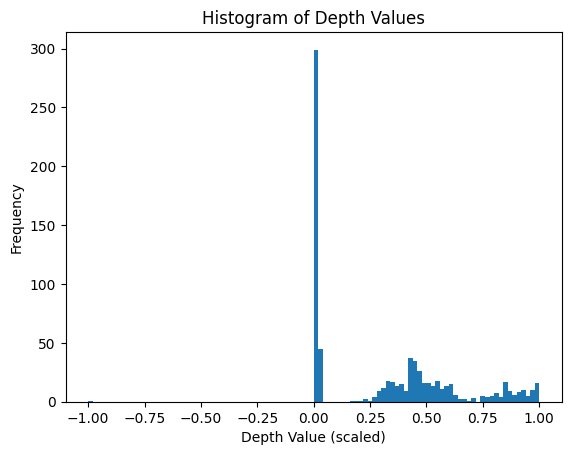

In [14]:
# Histogram of depth values
plt.hist(viz_obs[..., 3].cpu().numpy().flatten(), bins=100)
plt.title('Histogram of Depth Values')
plt.xlabel('Depth Value (scaled)')
plt.ylabel('Frequency')
plt.show()

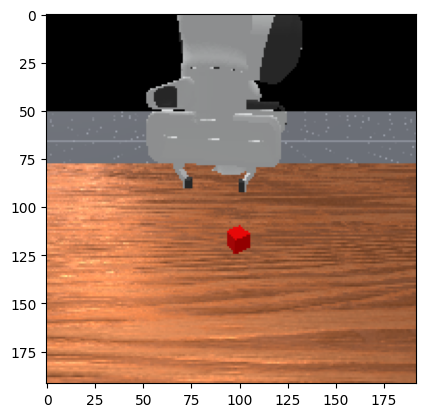

In [15]:
plt.imshow(obs['sensor_data']['base_camera']['rgb'].squeeze().cpu().numpy())